# 导入numpy计算库

In [22]:
import numpy as np

# 任务1：实现线性模型

## 1.1 Softmax计算

- 输入x：一个K维的向量
- 输出o：一个K维的向量
- 计算过程
    - $o = \exp(x)$ 这是一个向量
    - $sum\_{o} = \sum{o}$ 这是一个标量
    - $o = \frac{o}{sum\_o}$
- 使用的函数请参考文档，包括np.exp、np.sum等

In [23]:
def softmax(x: np.ndarray) -> np.ndarray:
    # TODO: 计算输入Numpy向量x的softmax函数计算结果
    o = np.exp(x)
    sum_o = np.sum(o)
    o /= sum_o
    return o

## 1.2 验证softmax模块

输出结果大致为$[0.032,  0.087,  0.237,  0.644]$

In [24]:
x = np.array([1, 2, 3, 4])
o = softmax(x)
print(o)

[0.0320586  0.08714432 0.23688282 0.64391426]


## 1.3 模型正向预测
- 输入x：一个K维的向量
- 输入weight：一个N * K维的矩阵
- 输入bias：一个N维的向量
- 输出o：一个N维的概率向量
- 计算过程：
    - 利用线性模型得到输出：$o=w*x+b$
    - 用你实现的softmax对输出进行处理，得到概率向量：$o=softmax(o)$
    
可能用到np.matmul等函数。

In [25]:
def forward(x: np.ndarray, weight: np.ndarray, bias: np.ndarray) -> np.ndarray:
    # TODO: 先用线性计算得到o，再对o使用softmax函数得到最终输出o
    o = np.matmul(weight, x) + bias
    o = softmax(o)
    return o

## 1.4 验证正向预测过程

输出结果大致为[9.11e-04 9.99e-01]

In [26]:
w = np.array([[1, 2], [3, 4]])
b = np.array([1, 2])
x = np.array([1, 2])
y = forward(x, w, b)
print(y)

[9.11051194e-04 9.99088949e-01]


# 任务2：计算损失函数
- 输入y：一个整数，表示真实标签
- 输入o：一个N维向量，表示模型的预测概率（已经经过softmax处理了的模型输出结果）
- 输出loss：一个实数，表示损失函数的计算结果
- 计算过程：
    - 先对y做onehot转换： $𝑦_{onehot}$只有在$𝑗=𝑦$的位置等于1，否则等于0
    - 再计算交叉熵loss： $L=-\sum{y_{onehot}*ln(o)}$

这里可能用到np.log等函数

In [27]:
def cross_entropy_loss(y: np.int_, o: np.ndarray) -> np.float32:
    label_num = o.shape[0]
    y_onehot = np.zeros(label_num)
    
    # TODO: 把y转换到y_onehot上，然后计算交叉熵loss
    y_onehot[y] = 1
    loss = -np.sum(np.dot(y_onehot, np.log(o)))
    
    return loss

def distance_as_loss(y: np.int_, o: np.ndarray) -> np.float32:
    label_num = o.shape[0]
    y_onehot = np.zeros(label_num)
    y_onehot[y] = 1
    loss = np.sum(np.square(o - y_onehot))
    
    return loss

## 验证损失函数计算
输出结果大致为0.6931

In [28]:
y = 0
o = np.array([0.5, 0.25, 0.25])
print(cross_entropy_loss(y, o))
print(distance_as_loss(y, o))

0.6931471805599453
0.375


# 任务3：实现梯度计算过程

- 输入x：一个K维的向量
- 输入o：一个N维的向量
- 输入y：一个整数的标签
- 输入weight：一个N * K维的矩阵
- 输入bias：一个N维的向量
- 输出weight_grad：一个N * K维的矩阵，是由loss计算到的weight的梯度
- 输出bias_grad：一个N维的向量，是由loss计算到的bias的梯度
- weight_grad计算由链式求导法则可得：$\nabla w = (o-y_{onehot})\times x$
- bias_grad计算由链式求导法则可得：$\nabla b = o-y_{onehot}$

这里可能会用到np.outer函数。

In [29]:
def backward(x: np.ndarray, o: np.ndarray, y: np.int_, weight: np.ndarray, bias: np.ndarray, loss_type="ce") -> (np.ndarray, np.ndarray):
    label_num = o.shape[0]
    y_onehot = np.zeros(label_num)
    
    # TODO: 把y转换到y_onehot上，然后计算模型参数的梯度
    y_onehot[y] = 1
    if loss_type == 'ce':
        # 交叉熵 + Softmax 的简化梯度：(o - y)
        delta = o - y_onehot
    else:
        # MSE + Softmax 的真实梯度：2 * (o - y) * softmax_derivative
        # 简化版：这里演示 MSE 为什么慢，核心在于它多乘了输出的概率分布
        # 真正的 Softmax 梯度较复杂，这里用简单的 (o-y)*o*(1-o) 模拟其饱和特性
        delta = 2 * (o - y_onehot) * o * (1 - o)
    
    weight_grad = np.outer(delta, x)
    bias_grad = delta
    return weight_grad, bias_grad

## 验证梯度计算公式

输出结果大致为(array([[ 0.00091105,  0.0018221 ],
       [-0.00091105, -0.0018221 ]]), array([ 0.00091105, -0.00091105]))

In [30]:
w = np.array([[1, 2], [3, 4]])
b = np.array([1, 2])
x = np.array([1, 2])
y = 1
o = forward(x, w, b)
print(backward(x, o, y, w, b))

(array([[ 0.00091105,  0.0018221 ],
       [-0.00091105, -0.0018221 ]]), array([ 0.00091105, -0.00091105]))


# 任务4：模型训练



## 准备步骤

加载数据，初始化模型参数，定义关键变量

In [31]:
label_num = 3
input_size = 13

epoches = 1000
learning_rate = 0.1

trainset = np.load("trainset.npy", allow_pickle=True)
testset = np.load("testset.npy", allow_pickle=True)

weight = np.random.uniform(-0.1, 0.1, (label_num, input_size))
bias = np.random.uniform(-0.1, 0.1, label_num)

## 模型训练
- 应用上述模块进行训练
- 实现梯度下降更新
    - $w = w-lr*\frac{\sum{w}}{count}$ , $b = b-lr*\frac{\sum{b}}{count}$

如果上述三个模块实现正确，loss将越来越小、逐渐收敛。


In [32]:
def train(epoches: int, learning_rate: float, log: bool = False, weight = None, bias = None, loss_func = cross_entropy_loss):
    if weight is None:
        weight = np.random.uniform(-0.1, 0.1, (label_num, input_size))
    if bias is None:
        bias = np.random.uniform(-0.1, 0.1, label_num)
    for epoch in range(1, epoches+1):
        
        total_loss = total_weight_grad = total_bias_grad = 0
        count = 0
        
        for x, y in trainset:
            
            # TODO: 得到模型预测结果o
            o = forward(x, weight, bias)
            
            # TODO: 计算损失函数loss
            loss = loss_func(y, o)
            
            # TODO: 计算梯度
            weight_grad, bias_grad = backward(x, o, y, weight, bias)
            
            count += 1
            total_loss += loss
            total_weight_grad += weight_grad
            total_bias_grad += bias_grad
        
        # TODO：利用total_weight_grad和weight_grad对weight和bias做更新，实现SGD公式
        weight = weight - learning_rate * total_weight_grad / count
        bias = bias - learning_rate * total_bias_grad / count
        
        avg_loss = total_loss / count
        
        # 每20个epoch打印一次
        if log and epoch % 20 == 0:
            print('epoch=%d, averaged loss=%.3f' % (epoch, avg_loss))
    return weight, bias

In [33]:
weight, bias = train(epoches, learning_rate, log=True)

epoch=20, averaged loss=0.963
epoch=40, averaged loss=0.863
epoch=60, averaged loss=0.781
epoch=80, averaged loss=0.713
epoch=100, averaged loss=0.656
epoch=120, averaged loss=0.608
epoch=140, averaged loss=0.567
epoch=160, averaged loss=0.531
epoch=180, averaged loss=0.501
epoch=200, averaged loss=0.474
epoch=220, averaged loss=0.450
epoch=240, averaged loss=0.430
epoch=260, averaged loss=0.411
epoch=280, averaged loss=0.394
epoch=300, averaged loss=0.379
epoch=320, averaged loss=0.365
epoch=340, averaged loss=0.352
epoch=360, averaged loss=0.341
epoch=380, averaged loss=0.330
epoch=400, averaged loss=0.320
epoch=420, averaged loss=0.311
epoch=440, averaged loss=0.303
epoch=460, averaged loss=0.295
epoch=480, averaged loss=0.288
epoch=500, averaged loss=0.281
epoch=520, averaged loss=0.274
epoch=540, averaged loss=0.268
epoch=560, averaged loss=0.263
epoch=580, averaged loss=0.257
epoch=600, averaged loss=0.252
epoch=620, averaged loss=0.247
epoch=640, averaged loss=0.243
epoch=660, a

# 任务5：验证模型准确度

## 实现准确度计算模块

In [13]:
def calc_accuracy(weight, bias, dataset):
    # 返回模型在数据集上的预测准确率
    
    correct = 0
    count = 0
    for x, y in dataset:
        
        # TODO：获取模型预测结果
        o = forward(x, weight, bias)
        
        # TODO: 取出模型置信度最大是哪个维度
        result = np.argmax(o)
        
        # TODO：比较模型预测结果，计算correct（正确计数）和count（总量计数）
        # 如果result等于y，则correct+1；count不管判断正确与否始终+1
        count += 1
        if result == y:
            correct += 1

    acc = correct / count
    return acc

## 计算准确度 
计算并输出模型在trainset和test上的预测准确率

In [14]:
# TODO: 统计训练集和测试集上的准确率
train_acc = calc_accuracy(weight, bias, trainset)
test_acc = calc_accuracy(weight, bias, testset)

print(train_acc, test_acc)

0.98 1.0


In [15]:
# 超参数验证
import matplotlib.pyplot as plt
import pandas as pd

def test(loss_func = cross_entropy_loss, file: str = "plot.png"):
    learning_rates = [0.001, 0.002, 0.003, 0.004, 0.006, 0.008, 0.01, 0.015]
    epoches = 1200
    step = 50
    
    # 用于存储结果的列表
    results = []

    for learning_rate in learning_rates:
        epochs = 0
        weight = np.random.uniform(-0.1, 0.1, (label_num, input_size))
        bias = np.random.uniform(-0.1, 0.1, label_num)
        while epochs <= epoches:
            epochs += step
            weight, bias = train(step, learning_rate, log=False, weight=weight, bias=bias, loss_func=loss_func)
            train_acc = calc_accuracy(weight, bias, trainset)
            test_acc = calc_accuracy(weight, bias, testset)
            
            print(f"epochs: {epochs}, learning_rate: {learning_rate}, train_acc: {train_acc}, test_acc: {test_acc}")
            
            # 将结果存入列表
            results.append({
                'learning_rate': learning_rate,
                'epochs': epochs,
                'train_acc': train_acc,
                'test_acc': test_acc
            })

    # 转化为 DataFrame 方便绘图
    df = pd.DataFrame(results)
    plot_results(df, file)

def plot_results(df, file: str):
    plt.figure(figsize=(12, 12))
    
    # 遍历每个学习率，画出对应的准确率曲线
    for lr in df['learning_rate'].unique():
        subset = df[df['learning_rate'] == lr]
        
        # 画出测试集准确率（实线）
        plt.plot(subset['epochs'], subset['test_acc'], marker='o', label=f'LR={lr} (Test)')
        
        # 如果你想同时看训练集准确率，可以取消下面这行的注释（虚线）
        # plt.plot(subset['epochs'], subset['train_acc'], linestyle='--', alpha=0.5, label=f'LR={lr} (Train)')

    plt.title('Accuracy vs Epochs for different Learning Rates', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(title="Learning Rate", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(file, dpi=300, bbox_inches='tight')
    plt.show()

epochs: 50, learning_rate: 0.001, train_acc: 0.36666666666666664, test_acc: 0.35714285714285715
epochs: 100, learning_rate: 0.001, train_acc: 0.36666666666666664, test_acc: 0.32142857142857145
epochs: 150, learning_rate: 0.001, train_acc: 0.3466666666666667, test_acc: 0.32142857142857145
epochs: 200, learning_rate: 0.001, train_acc: 0.34, test_acc: 0.32142857142857145
epochs: 250, learning_rate: 0.001, train_acc: 0.34, test_acc: 0.32142857142857145
epochs: 300, learning_rate: 0.001, train_acc: 0.34, test_acc: 0.32142857142857145
epochs: 350, learning_rate: 0.001, train_acc: 0.34, test_acc: 0.32142857142857145
epochs: 400, learning_rate: 0.001, train_acc: 0.34, test_acc: 0.32142857142857145
epochs: 450, learning_rate: 0.001, train_acc: 0.34, test_acc: 0.32142857142857145
epochs: 500, learning_rate: 0.001, train_acc: 0.34, test_acc: 0.32142857142857145
epochs: 550, learning_rate: 0.001, train_acc: 0.3333333333333333, test_acc: 0.32142857142857145
epochs: 600, learning_rate: 0.001, train_

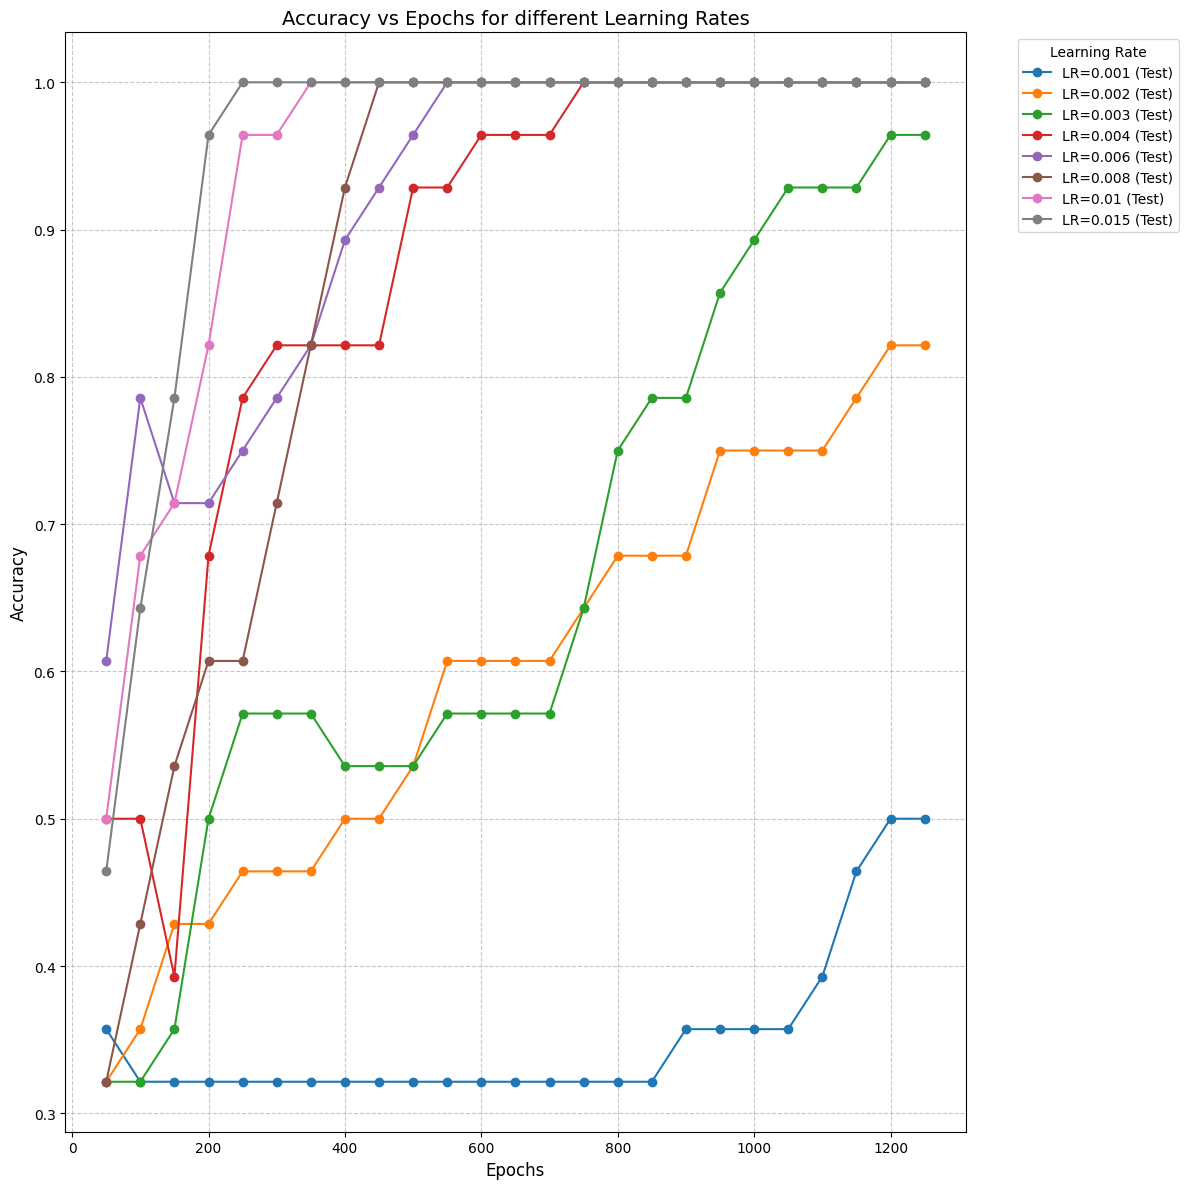

In [16]:
test(file="cross.png")

In [17]:
# 损失函数验证
weight, bias = train(epoches, learning_rate, log=True,loss_func=distance_as_loss)

epoch=20, averaged loss=0.587
epoch=40, averaged loss=0.517
epoch=60, averaged loss=0.457
epoch=80, averaged loss=0.407
epoch=100, averaged loss=0.365
epoch=120, averaged loss=0.331
epoch=140, averaged loss=0.301
epoch=160, averaged loss=0.277


epoch=180, averaged loss=0.256
epoch=200, averaged loss=0.238
epoch=220, averaged loss=0.222
epoch=240, averaged loss=0.209
epoch=260, averaged loss=0.197
epoch=280, averaged loss=0.187
epoch=300, averaged loss=0.177
epoch=320, averaged loss=0.169
epoch=340, averaged loss=0.162
epoch=360, averaged loss=0.155
epoch=380, averaged loss=0.149
epoch=400, averaged loss=0.143
epoch=420, averaged loss=0.138
epoch=440, averaged loss=0.134
epoch=460, averaged loss=0.129
epoch=480, averaged loss=0.126
epoch=500, averaged loss=0.122
epoch=520, averaged loss=0.118
epoch=540, averaged loss=0.115
epoch=560, averaged loss=0.112
epoch=580, averaged loss=0.110
epoch=600, averaged loss=0.107
epoch=620, averaged loss=0.104
epoch=640, averaged loss=0.102
epoch=660, averaged loss=0.100
epoch=680, averaged loss=0.098
epoch=700, averaged loss=0.096
epoch=720, averaged loss=0.094
epoch=740, averaged loss=0.092
epoch=760, averaged loss=0.091
epoch=780, averaged loss=0.089
epoch=800, averaged loss=0.087
epoch=82

In [20]:
train_acc = calc_accuracy(weight, bias, trainset)
test_acc = calc_accuracy(weight, bias, testset)

print(train_acc, test_acc)

0.98 1.0


epochs: 50, learning_rate: 0.001, train_acc: 0.26666666666666666, test_acc: 0.32142857142857145


epochs: 100, learning_rate: 0.001, train_acc: 0.28, test_acc: 0.32142857142857145
epochs: 150, learning_rate: 0.001, train_acc: 0.3333333333333333, test_acc: 0.35714285714285715
epochs: 200, learning_rate: 0.001, train_acc: 0.4666666666666667, test_acc: 0.6071428571428571
epochs: 250, learning_rate: 0.001, train_acc: 0.54, test_acc: 0.6071428571428571
epochs: 300, learning_rate: 0.001, train_acc: 0.56, test_acc: 0.6071428571428571
epochs: 350, learning_rate: 0.001, train_acc: 0.5466666666666666, test_acc: 0.6071428571428571
epochs: 400, learning_rate: 0.001, train_acc: 0.5733333333333334, test_acc: 0.6428571428571429
epochs: 450, learning_rate: 0.001, train_acc: 0.5533333333333333, test_acc: 0.6785714285714286
epochs: 500, learning_rate: 0.001, train_acc: 0.5466666666666666, test_acc: 0.75
epochs: 550, learning_rate: 0.001, train_acc: 0.5466666666666666, test_acc: 0.75
epochs: 600, learning_rate: 0.001, train_acc: 0.5333333333333333, test_acc: 0.6785714285714286
epochs: 650, learning_r

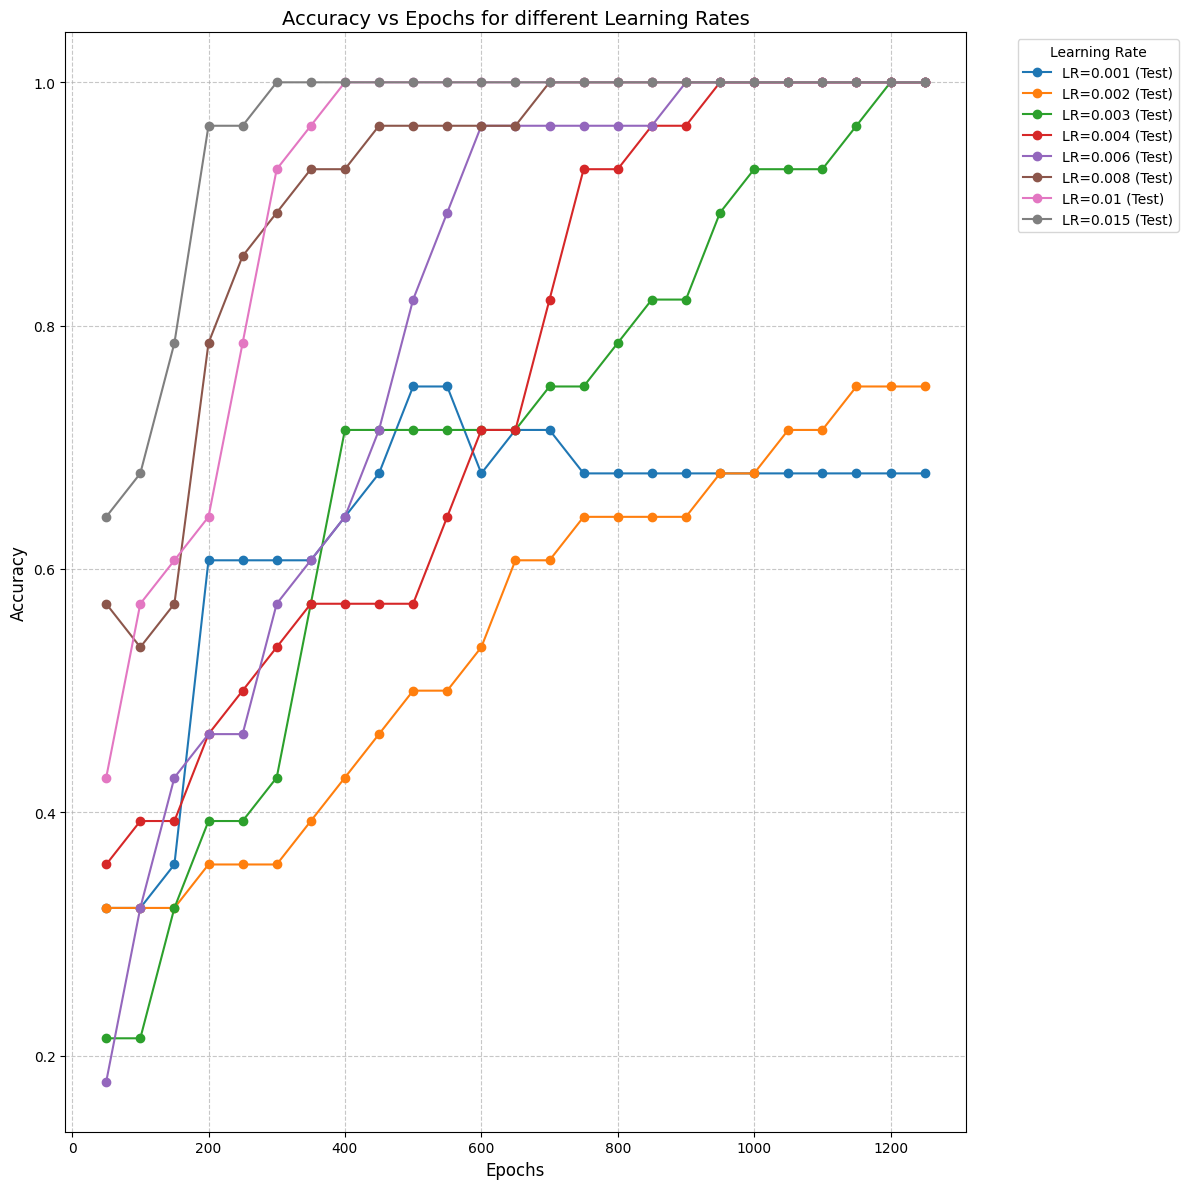

In [19]:
test(loss_func=distance_as_loss, file="distance.png")